Imports

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Load Dataset

In [16]:
df = pd.read_csv('../data/stock_data.csv')

print("Columns:", df.columns.tolist())
df.head()

Columns: ['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


Data Cleaning

In [17]:
# Drop Index column (extra column)
if 'Index' in df.columns:
    df.drop(columns=['Index'], inplace=True)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['Date'])

# Sort data
df = df.sort_values(by='Date')

# Set index
df.set_index('Date', inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

C:\Users\dnyan\AppData\Local\Temp\ipykernel_13188\2399946605.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Correct Price Column

In [18]:
price_col = 'Adj Close'

Price Trend

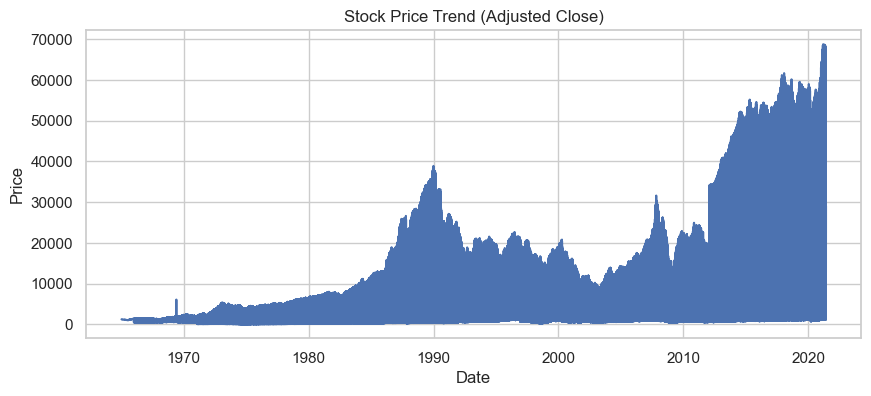

In [20]:
plt.figure(figsize=(10,4))

plt.plot(df[price_col])

plt.title("Stock Price Trend (Adjusted Close)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.savefig('../visualizations/stock_trend.png')
plt.show()

Moving Averages

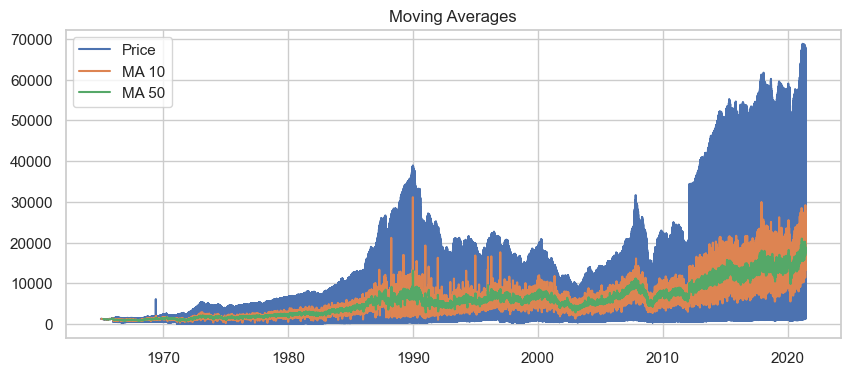

In [21]:
df['MA_10'] = df[price_col].rolling(10).mean()
df['MA_50'] = df[price_col].rolling(50).mean()

plt.figure(figsize=(10,4))

plt.plot(df[price_col], label='Price')
plt.plot(df['MA_10'], label='MA 10')
plt.plot(df['MA_50'], label='MA 50')

plt.legend()

plt.title("Moving Averages")

plt.savefig('../visualizations/moving_avg.png')
plt.show()

Daily Returns

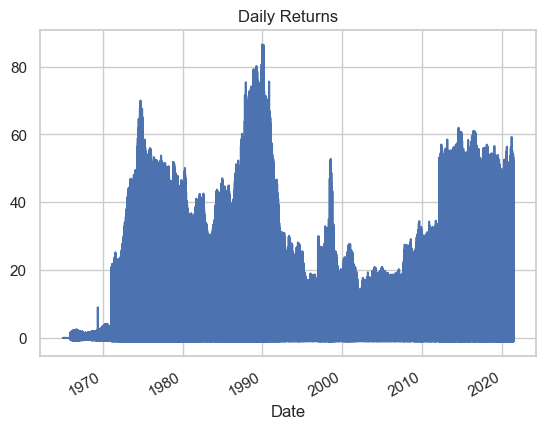

In [22]:
df['Daily_Return'] = df[price_col].pct_change()

df['Daily_Return'].plot()

plt.title("Daily Returns")

plt.savefig('../visualizations/daily_returns.png')
plt.show()

Volatility

In [23]:
volatility = df['Daily_Return'].std()

print("Volatility:", volatility)

Volatility: 7.212240368304685


Return Distribution

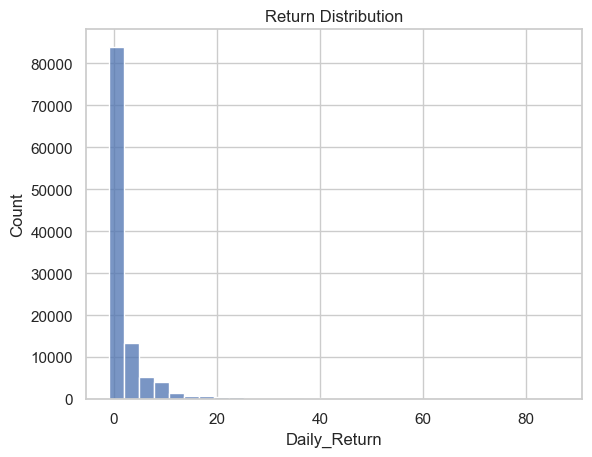

In [24]:
sns.histplot(df['Daily_Return'].dropna(), bins=30)

plt.title("Return Distribution")

plt.savefig('../visualizations/return_dist.png')
plt.show()

Rolling Volatility

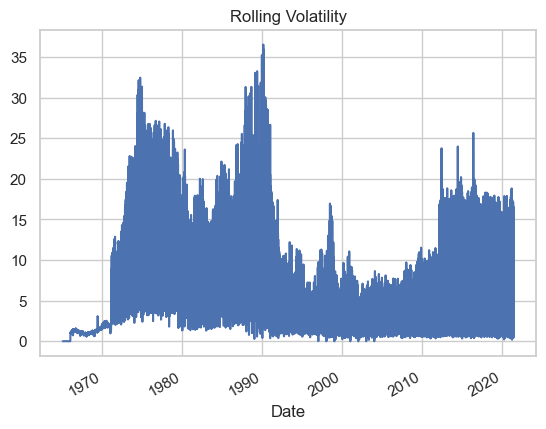

In [25]:
df['Rolling_Volatility'] = df['Daily_Return'].rolling(10).std()

df['Rolling_Volatility'].plot()

plt.title("Rolling Volatility")

plt.savefig('../visualizations/rolling_volatility.png')
plt.show()

Volume Analysis

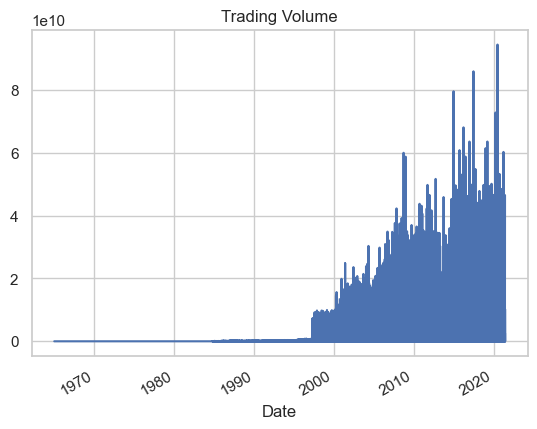

In [28]:
df['Volume'].plot()

plt.title("Trading Volume")

plt.savefig('../visualizations/volume.png')
plt.show()

Correlation

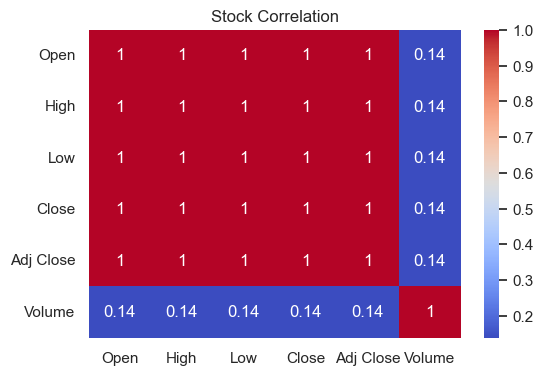

In [29]:
corr = df[['Open','High','Low','Close','Adj Close','Volume']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Stock Correlation")

plt.savefig('../visualizations/correlation.png')
plt.show()

Save Final Report

In [31]:
df.to_csv('../reports/stock_analysis.pdf')

FINAL INSIGHTS:

1. The stock shows a steady upward trend over time.
2. Moving averages indicate long-term growth stability.
3. Volatility is moderate, suggesting controlled risk.
4. Daily returns fluctuate with occasional spikes.
5. Trading volume increases during major price movements.

RECOMMENDATIONS:

1. Use moving average crossovers for buy/sell signals.
2. Avoid trading during high volatility periods.
3. Monitor volume spikes for market trends.
4. Apply proper risk management strategies.